# How much do Oscar-nominated films typically cost to make?

Graphs replicate `oscars.sql` using the datasets in `output/` (`oscars_2.csv` is the `oscars` table).
Focus: the **Directing** category, ceremonies 2000-2026.

Pipeline mirrors the SQL views:
- `directing_nominees` — Oscar `DIRECTING` rows joined to `tmdb` by `FilmId = imdb_id` to get the film title.
- `directing_financials` — those re-joined to `tmdb` by title for budget/revenue (`budget > 10000`, `revenue > 0`, release year 2000-2026). Row count = **111**, matching the SQL check.

In [4]:
import re
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# datasets from output/  (oscars_2.csv is the 'oscars' table)
oscars = pd.read_csv('output/oscars_2.csv')
ratings = pd.read_csv('output/ratings.csv', usecols=['tconst', 'averageRating'])

# The raw TMDB CSV is large, so keep this notebook on the cached slim version.
TMDB_COLS = ['imdb_id', 'title', 'budget', 'revenue', 'release_date', 'vote_count', 'genres']
TMDB_CACHE = Path('output/tmdb_slim.parquet')

try:
    tmdb = pd.read_parquet(TMDB_CACHE, columns=TMDB_COLS)
except (FileNotFoundError, OSError, ImportError, ValueError):
    tmdb = pd.read_csv('output/tmdb.csv', usecols=TMDB_COLS)
    try:
        tmdb.to_parquet(TMDB_CACHE, index=False)
    except (ImportError, ValueError):
        pass

tmdb['release_date'] = pd.to_datetime(tmdb['release_date'], errors='coerce')
tmdb['ry'] = tmdb['release_date'].dt.year

# leading 4-digit year from Oscar 'Year' (e.g. '1927/28' -> 1927)
def osc_year(v):
    m = re.match(r'(\d{4})', str(v))
    return int(m.group(1)) if m else np.nan
oscars['yr'] = oscars['Year'].apply(osc_year)

# ---- OSCAR palette: gold / amber (distinct from the blue used in low_budget_movies) ----
INK       = '#0b0b0b'
SECONDARY = '#52514e'
GRID      = '#e6e6e3'
SURFACE   = '#fcfcfb'
GOLD = ['#f4d584', '#ecc24f', '#e0a81f', '#c2870f', '#9c6a0a', '#734d05']  # light -> dark
GOLD_MAIN = '#c2870f'
POS, NEG  = '#1baf7a', '#e34948'

sns.set_theme(
    style='whitegrid', context='talk',
    rc={
        'figure.facecolor': SURFACE, 'axes.facecolor': SURFACE, 'savefig.facecolor': SURFACE,
        'axes.edgecolor': GRID, 'grid.color': GRID, 'grid.linewidth': 0.8,
        'axes.spines.top': False, 'axes.spines.right': False, 'axes.spines.left': False,
        'text.color': INK, 'axes.labelcolor': SECONDARY, 'axes.titlecolor': INK,
        'xtick.color': SECONDARY, 'ytick.color': SECONDARY,
        'axes.titleweight': 'bold', 'axes.titlesize': 15,
    },
)

def style_axes(ax, xlabel=None, ylabel=None, title=None, ygrid=True):
    if title: ax.set_title(title, loc='left', pad=14)
    ax.set_xlabel(xlabel or ''); ax.set_ylabel(ylabel or '')
    ax.tick_params(length=0)
    ax.grid(axis='y' if ygrid else 'x', color=GRID)
    ax.grid(axis='x' if ygrid else 'y', visible=False)

# ---- build directing_nominees / directing_financials (SQL views) ----
dir_nom = (oscars[(oscars.Category == 'DIRECTING') & oscars.yr.between(2000, 2026)]
           .merge(tmdb[['imdb_id', 'title']], left_on='FilmId', right_on='imdb_id', how='left')
           [['Year', 'title', 'Nominees', 'Winner']].rename(columns={'title': 'Film'}))

# De-dup only the titles we need, so this does not sort the whole TMDB table.
film_titles = dir_nom['Film'].dropna().unique()
tmdb_by_title = (tmdb[tmdb['title'].isin(film_titles)]
                 .sort_values('vote_count', ascending=False)
                 .drop_duplicates('title'))

dir_fin = (dir_nom.merge(tmdb_by_title, left_on='Film', right_on='title')
           .query('budget > 10000 and revenue > 0 and 2000 <= ry <= 2026').copy())
dir_fin['roi_pct'] = (dir_fin.revenue - dir_fin.budget) / dir_fin.budget * 100

print(f'tmdb {tmdb.shape} | directing_financials rows = {len(dir_fin)} (SQL check = 111)')


tmdb (1451806, 8) | directing_financials rows = 111 (SQL check = 111)


## Graph 1 — What does an Oscar-nominated film cost?
Distribution of `directing_financials` budgets. Dashed line = the SQL headline: average budget across directors with 2+ nominations (**~$50M**).

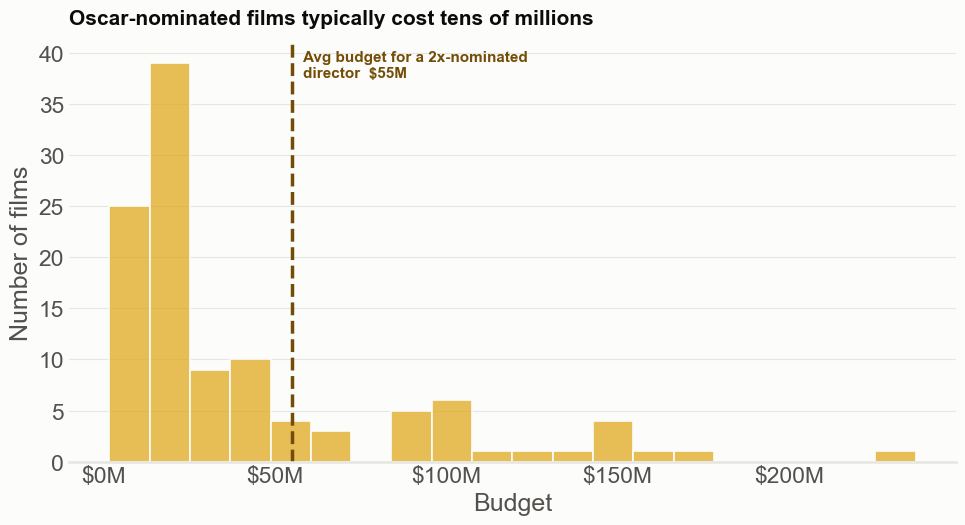

headline avg budget (>=2 noms) = $55.2M | median film budget = $25.0M


In [5]:
# SQL: AVG(avg_budget) over directors with >=2 nominations
by_dir = dir_fin.groupby('Nominees').agg(movies=('budget', 'size'), avg_budget=('budget', 'mean'))
headline = by_dir[by_dir.movies >= 2].avg_budget.mean()
median_budget = dir_fin.budget.median()

fig, ax = plt.subplots(figsize=(10, 5.6))
sns.histplot(dir_fin.budget / 1e6, bins=20, color=GOLD[2], edgecolor=SURFACE, linewidth=1.2, ax=ax)
ax.axvline(headline / 1e6, color=GOLD[5], linewidth=2.5, linestyle='--')
ax.text(headline / 1e6 + 3, ax.get_ylim()[1] * 0.92,
        f'Avg budget for a 2x-nominated\ndirector  ${headline/1e6:.0f}M', color=GOLD[5], fontweight='bold', fontsize=11)

style_axes(ax, xlabel='Budget', ylabel='Number of films',
           title='Oscar-nominated films typically cost tens of millions')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}M'))
plt.tight_layout()
plt.savefig('output/oscar1_budget_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'headline avg budget (>=2 noms) = ${headline/1e6:.1f}M | median film budget = ${median_budget/1e6:.1f}M')

## Graph 2 — Which genres win Oscars?
`main_genre` = first listed genre. Counts distinct Oscar-recognised films per genre (`revenue > 1000`, `vote_count > 500`, release year >= 2000).

/var/folders/6h/fxdk7zss6pbb3fd61nq6q__c0000gq/T/ipykernel_9549/3089222474.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=g2.values, y=g2.index, palette=pal, edgecolor=SURFACE, linewidth=2, orient='h', ax=ax)


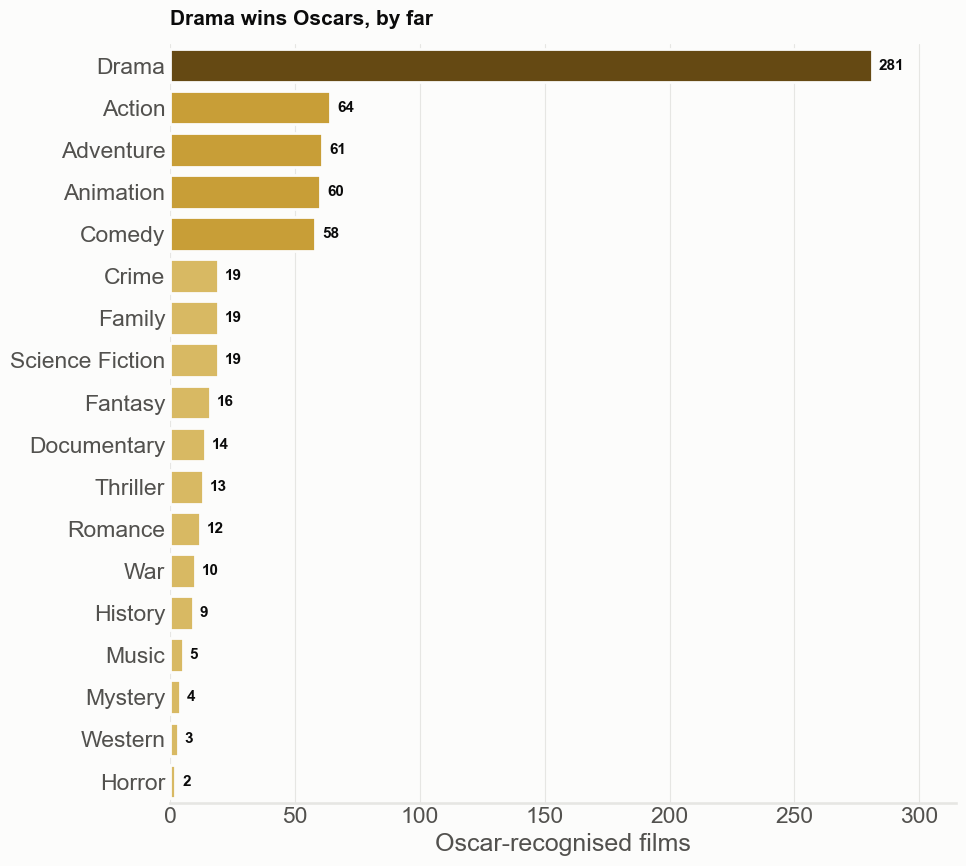

,movies
main_genre,
Drama,281
Action,64
Adventure,61
Animation,60
Comedy,58
Crime,19
Family,19
Science Fiction,19
Fantasy,16


In [6]:
oscar_films = oscars[oscars['FilmId'].notna()].copy()
oscar_ids = oscar_films['FilmId'].unique()
tmdb_for_oscars = tmdb[tmdb['imdb_id'].notna() & tmdb['imdb_id'].isin(oscar_ids)]

gj = oscar_films.merge(tmdb_for_oscars, left_on='FilmId', right_on='imdb_id')
gj = gj[(gj.revenue > 1000) & (gj.vote_count > 500) & (gj.ry >= 2000) &
        gj.genres.notna() & (gj.genres != '')].copy()
gj['main_genre'] = gj.genres.str.split(',').str[0].str.strip()
g2 = (gj.groupby('main_genre')['FilmId'].nunique()
      .sort_values(ascending=False).rename('movies'))

fig, ax = plt.subplots(figsize=(10, max(5, 0.5 * len(g2))))
# sequential gold by magnitude: darkest for the biggest
norm = (g2.values - g2.values.min()) / (g2.values.max() - g2.values.min() + 1e-9)
pal = [GOLD[1 + int(round(n * 4))] for n in norm]
sns.barplot(x=g2.values, y=g2.index, palette=pal, edgecolor=SURFACE, linewidth=2, orient='h', ax=ax)
for i, v in enumerate(g2.values):
    ax.text(v + g2.max() * 0.01, i, str(v), va='center', ha='left', color=INK, fontweight='bold', fontsize=11)

style_axes(ax, xlabel='Oscar-recognised films', title='Drama wins Oscars, by far', ygrid=False)
ax.set_xlim(right=g2.max() * 1.12)
plt.tight_layout()
plt.savefig('output/oscar2_genres.png', dpi=150, bbox_inches='tight')
plt.show()
g2.to_frame()


## Graph 3 — What ratings do Oscar-nominated films get?
`rating_group` share of distinct films, `CanonicalCategory = 'DIRECTING'`, ceremonies 2000-2026, joined to IMDb `ratings`.

/var/folders/6h/fxdk7zss6pbb3fd61nq6q__c0000gq/T/ipykernel_9549/694658742.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=order, y=share.values, palette=colors, edgecolor=SURFACE, linewidth=2, ax=ax)


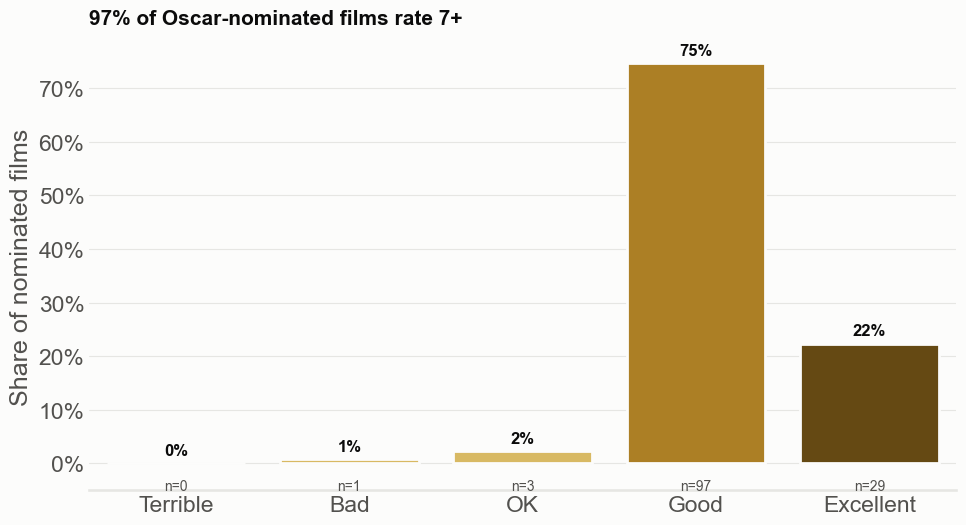

,movies,share_pct
rating_group,,
Terrible,0,0.00
Bad,1,0.77
OK,3,2.31
Good,97,74.62
Excellent,29,22.31


In [7]:
rj = oscars[(oscars.CanonicalCategory == 'DIRECTING') & oscars.yr.between(2000, 2026)] \
        .merge(ratings, left_on='FilmId', right_on='tconst')

def rating_group(v):
    if v < 4: return 'Terrible'
    if v < 6: return 'Bad'
    if v < 7: return 'OK'
    if v < 8: return 'Good'
    return 'Excellent'

rj['rating_group'] = rj.averageRating.apply(rating_group)
order = ['Terrible', 'Bad', 'OK', 'Good', 'Excellent']
counts = rj.groupby('rating_group')['FilmId'].nunique().reindex(order).fillna(0).astype(int)
share = (counts / counts.sum() * 100).round(2)

# 7-and-up = Good + Excellent
seven_up = share[['Good', 'Excellent']].sum()
colors = [GOLD[1], GOLD[1], GOLD[1], GOLD[3], GOLD[5]]  # highlight 7+ (Good, Excellent)

fig, ax = plt.subplots(figsize=(10, 5.6))
sns.barplot(x=order, y=share.values, palette=colors, edgecolor=SURFACE, linewidth=2, ax=ax)
for i, (v, n) in enumerate(zip(share.values, counts.values)):
    ax.text(i, v + 1, f'{v:.0f}%', ha='center', va='bottom', color=INK, fontweight='bold', fontsize=12)
    ax.text(i, -3, f'n={n}', ha='center', va='top', color=SECONDARY, fontsize=10)

style_axes(ax, ylabel='Share of nominated films',
           title=f'{seven_up:.0f}% of Oscar-nominated films rate 7+')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
ax.set_ylim(bottom=-5)
plt.tight_layout()
plt.savefig('output/oscar3_ratings.png', dpi=150, bbox_inches='tight')
plt.show()
pd.DataFrame({'movies': counts, 'share_pct': share})

## Graph 4 — Which nominated directors have the highest average ROI?
`directing_financials` grouped by director, `avg_roi = AVG((revenue-budget)/budget * 100)`, ordered descending. Top 15 shown; `n` = films in the set (many are single-film — high ROI on one lucky hit).

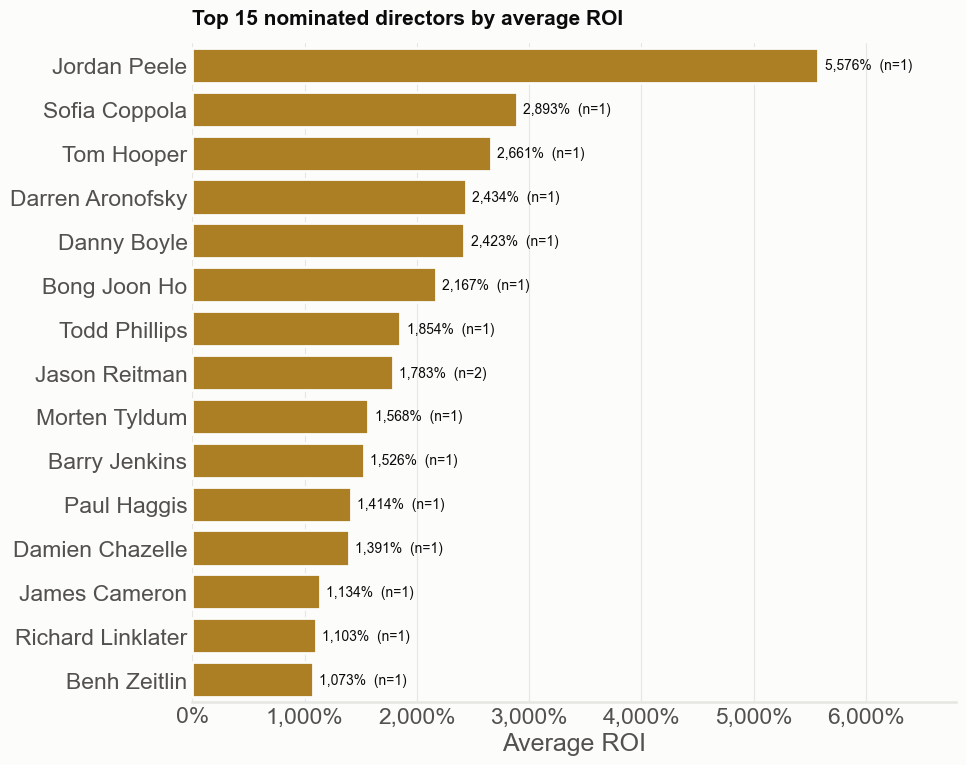

,movies,avg_roi
Nominees,,
Jordan Peele,1,5575.73
Sofia Coppola,1,2893.10
Tom Hooper,1,2661.41
Darren Aronofsky,1,2433.83
Danny Boyle,1,2422.74
Bong Joon Ho,1,2166.93
Todd Phillips,1,1853.56
Jason Reitman,2,1782.84
Morten Tyldum,1,1568.26


In [8]:
g4 = dir_fin.groupby('Nominees').agg(movies=('roi_pct', 'size'), avg_roi=('roi_pct', 'mean')) \
            .sort_values('avg_roi', ascending=False).round(2)
top = g4.head(15)

fig, ax = plt.subplots(figsize=(10, 8))
sns.barplot(x=top.avg_roi, y=top.index, color=GOLD_MAIN, edgecolor=SURFACE, linewidth=2, orient='h', ax=ax)
for i, (v, n) in enumerate(zip(top.avg_roi, top.movies)):
    ax.text(v + top.avg_roi.max() * 0.01, i, f'{v:,.0f}%  (n={n})', va='center', ha='left', color=INK, fontsize=10)

style_axes(ax, xlabel='Average ROI', title='Top 15 nominated directors by average ROI', ygrid=False)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}%'))
ax.set_xlim(right=top.avg_roi.max() * 1.22)
plt.tight_layout()
plt.savefig('output/oscar4_director_roi.png', dpi=150, bbox_inches='tight')
plt.show()
top

**Takeaways:** an Oscar-nominated director costs ~$50M in budget on average; **Drama** dominates Oscar recognition; **~97%** of nominated films rate 7+ on IMDb; and the highest-ROI directors are mostly one-film outliers (small `n`) rather than repeat performers.